# Test ballx and 4D table

In [1]:
import numpy as np
from scipy.interpolate import LinearNDInterpolator
import matplotlib.pyplot as plt

import jsbsim

jsbsim.FGJSBBase().debug_lvl = 0
AIRCRAFT_NAME="ballx"
PATH_TO_JSBSIM_FILES="../.."
fdm = jsbsim.FGFDMExec(PATH_TO_JSBSIM_FILES)
is_aircraft_loaded = fdm.load_model(AIRCRAFT_NAME)

if not is_aircraft_loaded:
    raise RuntimeError(f"Failed to load aircraft model '{AIRCRAFT_NAME}'")
else:
    print(f"Successfully loaded aircraft model '{AIRCRAFT_NAME}'")
    
    # Initialize dummy1 properties to avoid "property does not exist" error
    # when fdm.run() evaluates all aerodynamic functions.
    fdm['aero/dummy1/row-val'] = 0.0
    fdm['aero/dummy1/col-val'] = 0.0



In file ../../aircraft/ballx/ballx.xml: line 128
No direction element specified in force object. Default is (0,0,0).

  The aerodynamic moment axis system has been set by default to the bodyXYZ system.
Successfully loaded aircraft model 'ballx'


## Show a table `<function name="aero/dummy4D">` from `ballx.xml`

In [2]:
from pathlib import Path
import xml.etree.ElementTree as ET

xml_path = (Path(PATH_TO_JSBSIM_FILES) / "aircraft" / "ballx" / "ballx.xml").resolve()

root = ET.parse(xml_path).getroot()
dummy4d = root.find(".//function[@name='aero/dummy4D']")

if dummy4d is None:
    print("Function aero/dummy4D not found")
else:
    print("Function aero/dummy4D found. Showing the whole XML definition:\n======================\n")
    xml_text = ET.tostring(dummy4d, encoding="unicode")
    print('\t' + xml_text)

Function aero/dummy4D found. Showing the whole XML definition:

	<function name="aero/dummy4D">
          <description>
            Example 4-dimensional lookup table
          </description>
          <product>
            <value> 1.0 </value>
            <table>
              <independentVar lookup="row">aero/alpha-deg</independentVar>                
              <independentVar lookup="column">aero/beta-deg</independentVar>              
              <independentVar lookup="table">fcs/flap-pos-deg</independentVar>            
              <independentVar lookup="axis4">fcs/parachute_reef_pos_norm</independentVar> 

              <tableData breakPoint="0.0"> 
                <tableData breakPoint="0"> 
                                -5         0         5
                    -5.0      0.10      0.18      0.24
                     0.0      0.20      0.28      0.34
                     5.0      0.30      0.38      0.44
                    10.0      0.40      0.48      0.54
       

## Import matrices from `<tableData>` blocks

In [3]:
# Parse <function name="aero/dummy4D"> and import each leaf <tableData> as a 2D matrix.
# Also keep independentVar lookup values in separate arrays.

def parse_2d_table_block(tabledata_element):
    lines = [ln.strip() for ln in (tabledata_element.text or "").splitlines() if ln.strip()]
    if not lines:
        raise ValueError("Empty 2D <tableData> block")

    # First line: column axis values. Next lines: row axis value + matrix row values.
    axis2_values = np.array([float(v) for v in lines[0].split()], dtype=float)
    row_entries = [[float(v) for v in ln.split()] for ln in lines[1:]]

    axis1_values = np.array([row[0] for row in row_entries], dtype=float)
    matrix_2d = np.array([row[1:] for row in row_entries], dtype=float)

    return axis1_values, axis2_values, matrix_2d


table_node = dummy4d.find(".//table")
if table_node is None:
    raise RuntimeError("No <table> node found in aero/dummy4D")

# independentVar definitions (lookup attribute -> property path)
independent_vars = {
    iv.get("lookup", "row"): (iv.text or "").strip()
    for iv in table_node.findall("independentVar")
}

# axis4 breakpoints and axis3 breakpoints from nested tableData blocks
axis4_values = []
axis3_values = []

# Store each 2D table matrix keyed by (axis4_breakpoint, axis3_breakpoint)
table2d_by_axes = {}

for axis4_block in table_node.findall("tableData"):
    bp4 = float(axis4_block.get("breakPoint"))
    axis4_values.append(bp4)

    for axis3_block in axis4_block.findall("tableData"):
        bp3 = float(axis3_block.get("breakPoint"))
        axis3_values.append(bp3)

        a1_vals, a2_vals, matrix2d = parse_2d_table_block(axis3_block)
        table2d_by_axes[(bp4, bp3)] = matrix2d

# Unique/sorted axis arrays for independent variables
axis4_values = np.array(sorted(set(axis4_values)), dtype=float)
axis3_values = np.array(sorted(set(axis3_values)), dtype=float)
axis1_values = a1_vals
axis2_values = a2_vals

print("independent_vars:", independent_vars)
print("axis1_values (row):", axis1_values)
print("axis2_values (column):", axis2_values)
print("axis3_values (table):", axis3_values)
print("axis4_values:", axis4_values)
print()
print("Imported 2D matrices:")
for (bp4, bp3), matrix2d in sorted(table2d_by_axes.items()):
    print(f"axis4={bp4}, axis3={bp3}, shape={matrix2d.shape}")
    print(matrix2d)
    print()

independent_vars: {'row': 'aero/alpha-deg', 'column': 'aero/beta-deg', 'table': 'fcs/flap-pos-deg', 'axis4': 'fcs/parachute_reef_pos_norm'}
axis1_values (row): [-5.  0.  5. 10.]
axis2_values (column): [-5.  0.  5.]
axis3_values (table): [ 0. 20.]
axis4_values: [0. 1.]

Imported 2D matrices:
axis4=0.0, axis3=0.0, shape=(4, 3)
[[0.1  0.18 0.24]
 [0.2  0.28 0.34]
 [0.3  0.38 0.44]
 [0.4  0.48 0.54]]

axis4=0.0, axis3=20.0, shape=(4, 3)
[[5.22 5.3  5.36]
 [5.32 5.4  5.46]
 [5.42 5.5  5.56]
 [5.52 5.6  5.66]]

axis4=1.0, axis3=0.0, shape=(4, 3)
[[2.15 2.23 2.29]
 [2.25 2.33 2.39]
 [2.35 2.43 2.49]
 [2.45 2.53 2.59]]

axis4=1.0, axis3=20.0, shape=(4, 3)
[[10.27 10.35 10.41]
 [10.37 10.45 10.51]
 [10.47 10.55 10.61]
 [10.57 10.65 10.71]]



## Utility function extracting interpolated data via `fdm`

In [4]:
# Utility function to perform lookup in the 4D table
def jsbsim_lookup4D(row, col, axis3=0.0, axis4=0.0):
    fdm['aero/alpha-deg'] = row
    fdm['aero/beta-deg'] = col
    fdm['fcs/flap-pos-deg'] = axis3
    fdm['fcs/parachute_reef_pos_norm'] = axis4
    fdm.run()
    return fdm['aero/dummy4D']


## Plots the surfaces

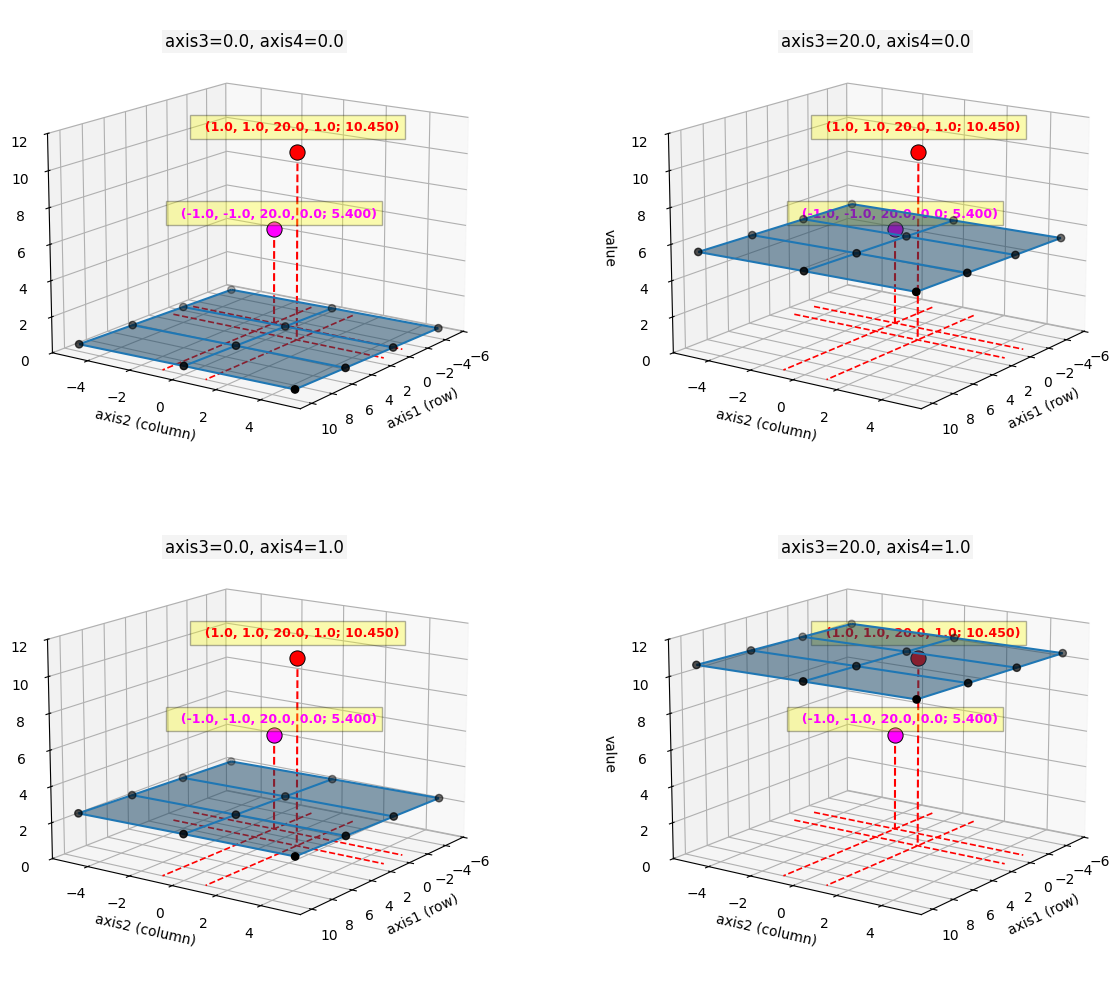

In [ ]:
# Plot all imported 2D surfaces as wireframes of axis_1 vs axis_2
import math

if not table2d_by_axes:
    raise RuntimeError("No 2D matrices found in table2d_by_axes")

# Build axis grid (matrix shape is len(axis1_values) x len(axis2_values))
A1, A2 = np.meshgrid(axis1_values, axis2_values, indexing="ij")

surfaces = sorted(table2d_by_axes.items())
n = len(surfaces)
ncols = 2 if n > 1 else 1
nrows = math.ceil(n / ncols)

fig = plt.figure(figsize=(7 * ncols, 5 * nrows))

x_min, x_max = float(np.min(axis1_values)), float(np.max(axis1_values))
y_min, y_max = float(np.min(axis2_values)), float(np.max(axis2_values))

for i, ((bp4, bp3), Z) in enumerate(surfaces, start=1):
    ax = fig.add_subplot(nrows, ncols, i, projection="3d")
    # Semi-transparent shaded surface.
    ax.plot_surface(A1, A2, Z, alpha=0.5, color="tab:blue", linewidth=0, antialiased=True)
    # Wireframe on top of the shaded surface.
    ax.plot_wireframe(A1, A2, Z, color="tab:blue")
    # Plot tabular breakpoint samples as dots on top of the wireframe.
    ax.scatter(A1.ravel(), A2.ravel(), Z.ravel(), color="k", s=28)

    # Interpolated lookup at row=1, col=1 for the current (axis3, axis4) slice.
    x0, y0 = 1.0, 1.0
    ax3 = 20.0
    ax4 = 1.0
    z_ = float(np.asarray(jsbsim_lookup4D(row=x0, col=y0, axis3=ax3, axis4=ax4)))
    ax.scatter([x0], [y0], [z_], 
               color="red", s=120, edgecolor="k", linewidth=0.7, alpha=1.0)
    ax.text(x0, y0, z_*1.10, f"  ({x0:.1f}, {y0:.1f}, {ax3:.1f}, {ax4:.1f}; {z_:.3f})", 
            ha="center", va="bottom",
            bbox=dict(facecolor='yellow', alpha=0.3),
            color="red", fontsize=9, weight="bold", alpha=1.0)

    # Dashed projection lines:
    # 1) from 3D point to the (axis1, axis2) plane at z = 0
    # 2) in-plane projections extended to plane limits along axis1 and axis2
    z_plane = 0
    ax.plot([x0, x0], [y0, y0], [z_, z_plane], "r--", linewidth=1.5)
    ax.plot([x_min, x_max], [y0, y0], [z_plane, z_plane], "r--", linewidth=1.2)
    ax.plot([x0, x0], [y_min, y_max], [z_plane, z_plane], "r--", linewidth=1.2)

    # Interpolated lookup at row=-1, col=-1 for the current (axis3, axis4) slice.
    x0, y0 = -1.0, -1.0
    ax3 = 20.0
    ax4 = 0.0
    z_ = float(np.asarray(jsbsim_lookup4D(row=x0, col=y0, axis3=ax3, axis4=ax4)))
    ax.scatter([x0], [y0], [z_], 
               color="magenta", s=120, edgecolor="k", linewidth=0.7, alpha=1.0)
    ax.text(x0, y0, z_*1.10, f"  ({x0:.1f}, {y0:.1f}, {ax3:.1f}, {ax4:.1f}; {z_:.3f})", 
            ha="center", va="bottom",
            bbox=dict(facecolor='yellow', alpha=0.3),
            color="magenta", fontsize=9, weight="bold", alpha=1.0)


    # Dashed projection lines:
    # 1) from 3D point to the (axis1, axis2) plane at z = 0
    # 2) in-plane projections extended to plane limits along axis1 and axis2
    z_plane = 0
    ax.plot([x0, x0], [y0, y0], [z_, z_plane], "r--", linewidth=1.5)
    ax.plot([x_min, x_max], [y0, y0], [z_plane, z_plane], "r--", linewidth=1.2)
    ax.plot([x0, x0], [y_min, y_max], [z_plane, z_plane], "r--", linewidth=1.2)

    ax.set_xlabel("axis1 (row)")
    ax.set_ylabel("axis2 (column)")
    ax.set_zlabel("value")
    ax.set_zlim(0.0, 12.0)
    ax.view_init(elev=15, azim=35)
    # In 3D plots, lowering y is usually more effective than changing pad.
    ax.set_title(
        f"axis3={bp3}, axis4={bp4}",
        y=0.98,
        bbox={"facecolor": "#f4f4f4", "edgecolor": "none", "pad": 2.0},
    )

plt.tight_layout(h_pad=3.0)
plt.show()

## Sean's example. See `aero/dumm1` function in `ballx.xml`

/usr/local/python/3.11.15/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in jsbsim_lookup2D (vectorized)
  outputs = ufunc(*args, out=...)


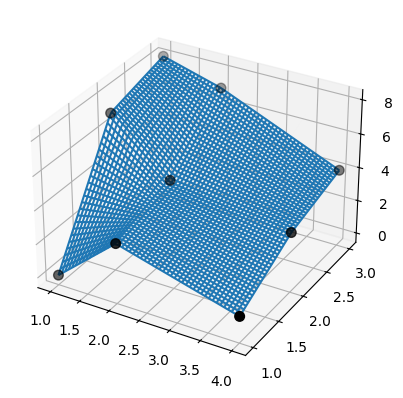

In [6]:
@np.vectorize
def jsbsim_lookup2D(row, col):
    fdm['aero/dummy1/row-val'] = row
    fdm['aero/dummy1/col-val'] = col
    fdm.run()
    return fdm['aero/dummy1']

x = np.array([1,1,1,2,2,2,4,4,4])
y = np.array([1,2,3,1,2,3,1,2,3])
z = np.array([0,7,8,3,4,7,1,3,4])

xy = np.c_[x, y]   # or just list(zip(x, y))
lut2 = LinearNDInterpolator(xy, z)
X = np.linspace(min(x), max(x))
Y = np.linspace(min(y), max(y))
X, Y = np.meshgrid(X, Y)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.view_init(elev=25, azim=-135)
ax.plot_wireframe(X, Y, jsbsim_lookup2D(X, Y))
ax.scatter(x, y, z,  'o', color='k', s=48)

plt.show()